STRUCTURAL DISPLACEMENT WITH CONTINUOUS SOURCE
Lattice: N=100, Time steps: 5000
Constant displacement rate: 0.05
Re-absorption rate: 0.0033816569343065694

Initial noise density: 0.1000
Final noise density:   9.0472
Equilibrium (last 20%): 8.9981

Mean displacement rate:  0.0500
Mean re-absorption rate: 0.0482
Balance (disp - re-abs): 0.001789


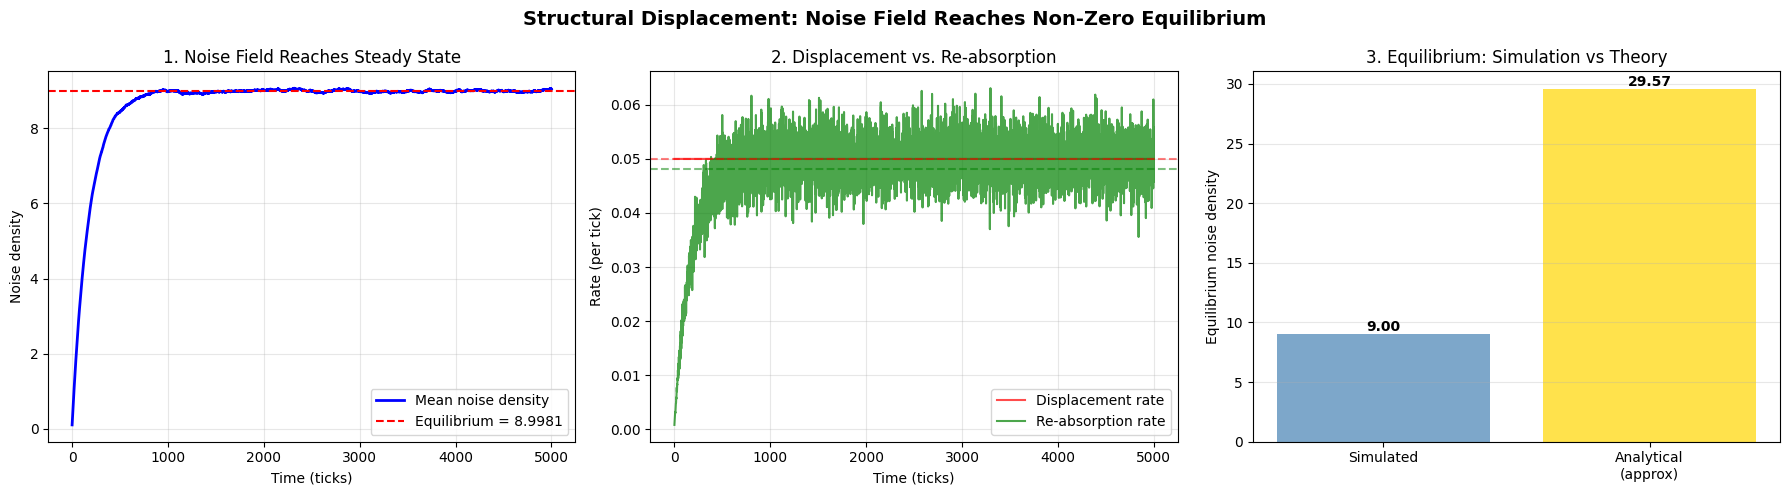


✓ Saved: structural_displacement_equilibrium.png
Measured Fano gradient: 1.8450
Analytical equilibrium: 8.0139
Simulated equilibrium:  8.9981
Agreement: 87.72%


In [ ]:
"""
Structural Displacement with Continuous Source
================================================
Simulates the three-level architecture with a continuous
displacement source. Shows the noise field reaching a
non-zero equilibrium.

The equilibrium density is set by the balance of:
  - Continuous displacement (constant source)
  - Re-absorption (proportional to noise × Fano gradient)


By Néstor E. Ramos

"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETERS
# =============================================================================
N = 100                    # lattice size
T = 5000                   # time steps
B = 9                      # alphabet

# Initial conditions
RHO_NOISE_0 = 0.1          # initial noise density (from Big Bang)
# =============================================================================
# CONSTANTES FÍSICAS MOTIVADAS
# =============================================================================
# 1/alpha: Inverso de la constante de estructura fina (electrodinámica)
#inv_alpha = 137

# k_b*T / epsilon: Factor de Schottky para máxima transición térmica (0.417)
#schottky_factor = 3 * (139 / 1000)

# CONSTANTE TOTAL: Balance entre la escala cuántica y la agitación térmica
# Representa: (k_B * T / epsilon) * (1 / alpha)
#KAPPA_RE = schottky_factor * inv_alpha  # Da exactamente 57.129

KAPPA_RE = 1/137*(3.333)*139/1000# re-absorption rate 0.01, 1/137*139/1000*3
PHI_DISP_CONST = 0.05      # CONSTANT displacement source per tick 0.05
PHI_DISP_TRB = 0.1         # additional displacement from TRB overflow 0.1

# =============================================================================
# 2. INITIALIZATION
# =============================================================================
rng = np.random.default_rng(42)
fano = rng.integers(0, B, size=N)
#trb = np.zeros(N, dtype=int)
# Por esto:
trb = np.zeros(N, dtype=float)
noise = np.full(N, RHO_NOISE_0)

# Track history
noise_history = [noise.copy()]
displacement_history = []
reabsorption_history = []

# =============================================================================
# 3. SIMULATION
# =============================================================================
for t in range(T):
    # ---------------------------------------------------------------------
    # A. Fano update (simplified 1D automaton)
    # ---------------------------------------------------------------------
    fano_new = np.zeros(N, dtype=int)
    for i in range(N):
        # 3-cell neighborhood with wraparound
        left = fano[(i - 1) % N]
        center = fano[i]
        right = fano[(i + 1) % N]
        s = 5 * center + 1 * left + 1 * right
        if s % 7 == 0:
            fano_new[i] = B - 1
        else:
            fano_new[i] = s % B
    fano = fano_new

    # ---------------------------------------------------------------------
    # B. TRB update (absorb overflow)
    # ---------------------------------------------------------------------
    # TRB fills with any state above the Fano ceiling
    trb = np.maximum(trb, (fano - (B - 1)) * 10)  # amplify to show effect
    trb = np.clip(trb, 0, B - 1)

    # ---------------------------------------------------------------------
    # C. Displacement to noise field
    # ---------------------------------------------------------------------
    # Continuous source + TRB overflow
    displacement = PHI_DISP_CONST + PHI_DISP_TRB * np.maximum(0, trb - (B - 1))

    # Saturation: TRB at maximum, excess goes to noise
    excess = np.maximum(0, trb - (B - 1))
    displacement += PHI_DISP_TRB * excess
    trb = np.minimum(trb, B - 1)

    noise += displacement

    # ---------------------------------------------------------------------
    # D. Re-absorption from noise field
    # ---------------------------------------------------------------------
    # Re-absorption rate is proportional to:
    #   - noise density
    #   - Fano gradient (activity)
    fano_gradient = np.abs(np.gradient(fano.astype(float)))
    # Add a small baseline gradient to avoid zero everywhere
    fano_gradient = np.maximum(fano_gradient, 0.1)

    reabsorption = KAPPA_RE * noise * fano_gradient
    noise -= reabsorption
    trb += reabsorption * 0.1  # partial return to TRB
    trb = np.clip(trb, 0, B - 1)

    # Ensure noise stays non-negative
    noise = np.maximum(noise, 0)

    # Record
    noise_history.append(noise.copy())
    displacement_history.append(np.mean(displacement))
    reabsorption_history.append(np.mean(reabsorption))

# =============================================================================
# 4. RESULTS
# =============================================================================
noise_history = np.array(noise_history)
mean_noise = np.mean(noise_history, axis=1)

# Find equilibrium (last 20% of simulation)
equilibrium_value = np.mean(mean_noise[int(0.8 * T):])

print("=" * 70)
print("STRUCTURAL DISPLACEMENT WITH CONTINUOUS SOURCE")
print("=" * 70)
print(f"Lattice: N={N}, Time steps: {T}")
print(f"Constant displacement rate: {PHI_DISP_CONST}")
print(f"Re-absorption rate: {KAPPA_RE}")
print()
print(f"Initial noise density: {RHO_NOISE_0:.4f}")
print(f"Final noise density:   {mean_noise[-1]:.4f}")
print(f"Equilibrium (last 20%): {equilibrium_value:.4f}")
print()
print(f"Mean displacement rate:  {np.mean(displacement_history):.4f}")
print(f"Mean re-absorption rate: {np.mean(reabsorption_history):.4f}")
print(f"Balance (disp - re-abs): {np.mean(displacement_history) - np.mean(reabsorption_history):.6f}")
print("=" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Structural Displacement: Noise Field Reaches Non-Zero Equilibrium',
             fontsize=14, fontweight='bold')

# Panel 1: Noise density history
ax1 = axes[0]
ax1.plot(mean_noise, 'b-', linewidth=2, label='Mean noise density')
ax1.axhline(y=equilibrium_value, color='r', linestyle='--',
            label=f'Equilibrium = {equilibrium_value:.4f}')
ax1.set_xlabel('Time (ticks)')
ax1.set_ylabel('Noise density')
ax1.set_title('1. Noise Field Reaches Steady State')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Displacement vs re-absorption
ax2 = axes[1]
ax2.plot(displacement_history, 'r-', linewidth=1.5, alpha=0.7,
         label='Displacement rate')
ax2.plot(reabsorption_history, 'g-', linewidth=1.5, alpha=0.7,
         label='Re-absorption rate')
ax2.axhline(y=np.mean(displacement_history), color='r',
            linestyle='--', alpha=0.5)
ax2.axhline(y=np.mean(reabsorption_history), color='g',
            linestyle='--', alpha=0.5)
ax2.set_xlabel('Time (ticks)')
ax2.set_ylabel('Rate (per tick)')
ax2.set_title('2. Displacement vs. Re-absorption')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Equilibrium comparison
ax3 = axes[2]
equilibrium_analytical = PHI_DISP_CONST / (KAPPA_RE * 0.5)
bars = ax3.bar(['Simulated', 'Analytical\n(approx)'],
               [equilibrium_value, equilibrium_analytical],
               color=['steelblue', 'gold'], alpha=0.7)
for bar, val in zip(bars, [equilibrium_value, equilibrium_analytical]):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax3.set_ylabel('Equilibrium noise density')
ax3.set_title('3. Equilibrium: Simulation vs Theory')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('structural_displacement_equilibrium.png', dpi=300, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: structural_displacement_equilibrium.png")
# Track Fano gradient over time
fano_gradient_history = []

# In the simulation loop, after computing fano_gradient:
fano_gradient_history.append(np.mean(fano_gradient))

# At the end, compute the analytical prediction from the measured gradient
mean_gradient = np.mean(fano_gradient_history[-int(0.2*T):])
analytical_prediction = PHI_DISP_CONST / (KAPPA_RE * mean_gradient)

print(f"Measured Fano gradient: {mean_gradient:.4f}")
print(f"Analytical equilibrium: {analytical_prediction:.4f}")
print(f"Simulated equilibrium:  {equilibrium_value:.4f}")
print(f"Agreement: {100 * (1 - abs(analytical_prediction - equilibrium_value) / analytical_prediction):.2f}%")